# See 
https://docs.rbr-global.com/sup/pressure-temperature-correction-of-pressure

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [42]:
rbrfilename='../../../SWOT_Cruise/RBRqu/N280_RBRQu_213896_20230818_1714_rebuilt.nc'

#outfilename='../../../SWOT_Cruise/RBRqu/N280_RBRQu_213896_20230818_1714_nonlinear_calibration.nc'
# outfilename='../../../SWOT_Cruise/RBRqu/N280_RBRQu_213896_20230818_1714_FES2022_calibration.nc'
outfilename='../../../SWOT_Cruise/RBRqu/N280_RBRQu_213896_20230818_1714_W310S245_Tcalibration.nc'

ncfile ='[BB23]_[BB23_REC]_[N280]_[multi(27)_nominal_instrument_height_asb]_[multi(3)_instrument_model]_[multi(27)_instrument_serial_number]_[no_outfile_append].nc'
basedir = '/home/jupyter-ubuntu/data/SWOT_Cruise/FV02/stacked_moorings_tp/'

# basedir2 = '/home/jupyter-ubuntu/data/SWOT_Cruise/FV02/stacked_moorings_adcp'
# adcpfiles = [
#     #f'{basedir2}/[BB23]_[BB23_REC]_[S245]_[5]_[Quartermaster]_[11795]_[no_outfile_append].nc',
#     #f'{basedir2}/[BB23]_[BB23_REC]_[W310]_[multi(2)_nominal_instrument_height_asb]_[multi(2)_instrument_model]_[multi(2)_instrument_serial_number]_[no_outfile_append].nc',
#     f'{basedir2}/[BB23]_[BB23_REC]_[N280]_[5]_[Longranger]_[24613]_[no_outfile_append].nc',
# ]

basedir2 = '/home/jupyter-ubuntu/data/SWOT_Cruise/FV01/Longranger/'
adcpfiles = [f'{basedir2}/[BB23]_[BB23_REC]_[N280]_[594]_[Longranger]_[24613]_[no_outfile_append].nc']

###
ds_P = xr.open_dataset(rbrfilename)
ds_T = xr.open_dataset(basedir+ncfile) 
ds_uv = xr.open_dataset(adcpfiles[0])

In [3]:
ds_T

<xarray.Dataset> Size: 27MB
Dimensions:      (z_nom: 27, time: 61920)
Coordinates:
  * z_nom        (z_nom) float64 216B -268.8 -263.8 -258.8 ... -28.75 -15.35
  * time         (time) datetime64[ns] 495kB 2023-04-19 ... 2023-05-31T23:59:00
    lat_nom      float64 8B ...
    lon_nom      float64 8B ...
Data variables:
    Temperature  (z_nom, time) float64 13MB ...
    Pressure     (z_nom, time) float64 13MB ...
    source       (z_nom) <U14 2kB ...
Attributes: (12/35)
    title:                           Mooring made by stacking multipe files
    institution:                     The University of Western Australia
    institution_division:            Ocean Dynamics
    source:                          D:\BB23(All)\data\moored_instrument_data...
    project:                         BB23
    history:                         
    ...                              ...
    nominal_instrument_height_asb:   81.182;11.182;21.182;31.182;41.182;61.18...
    nominal_instrument_orientation:  
    timezone:                        UTC
    process_level:                   2
    is_profile_data:                 0
    pimos_nickname:                  stacked_moorings_tp

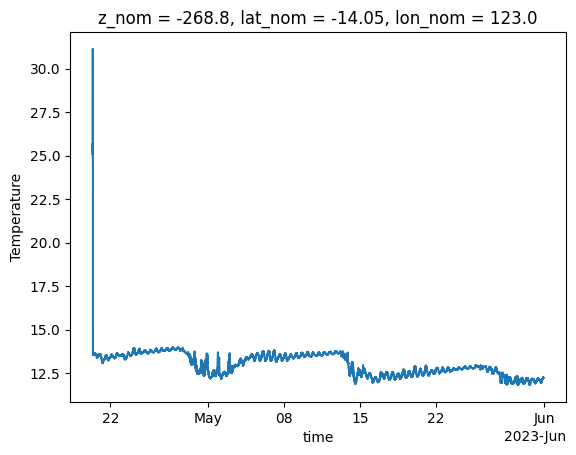

In [4]:
ds_T['Temperature'].isel(z_nom=0).plot()

In [5]:
ds_uv

<xarray.Dataset> Size: 934MB
Dimensions:              (time: 60656, distance: 140, beam: 4, x: 4, x*: 4,
                          earth: 3, inst: 3, dir: 4)
Coordinates:
  * time                 (time) datetime64[ns] 485kB 2023-04-19T22:00:00 ... ...
  * dir                  (dir) int64 32B 1 2 3 4
  * distance             (distance) float64 1kB 11.89 13.89 ... 287.9 289.9
  * beam                 (beam) int64 32B 1 2 3 4
  * x                    (x) int64 32B 1 2 3 4
  * x*                   (x*) int64 32B 1 2 3 4
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
    lat_nom              float64 8B ...
    lon_nom              float64 8B ...
    z_nom                float64 8B ...
    prof_z_nom           (distance) float64 1kB ...
Data variables: (12/32)
    number               (time) uint32 243kB ...
    builtin_test_fail    (time) bool 61kB ...
    c_sound              (time) float32 243kB ...
    depth                (time) float32 243kB ...
    pitch                (time) float32 243kB ...
    roll                 (time) float32 243kB ...
    ...                   ...
    vinst                (distance, time) float64 68MB ...
    winst                (distance, time) float64 68MB ...
    errvel               (distance, time) float64 68MB ...
    qc_velocity          (distance, time) float64 68MB ...
    sidelobe_last_good   (time) datetime64[ns] 485kB ...
    sidelobe_blank       (distance, time) bool 8MB ...
Attributes: (12/35)
    title:                           Measured data from a TDRI ADCP
    institution:                     The University of Western Australia
    institution_division:            Ocean Dynamics
    source:                          pIMOS
    project:                         BB23
    history:                         
    ...                              ...
    nominal_instrument_height_asb:   5.945
    nominal_instrument_orientation:  up
    timezone:                        UTC
    process_level:                   1
    is_profile_data:                 0
    pimos_nickname:                  Longranger

(272.0, 279.0)

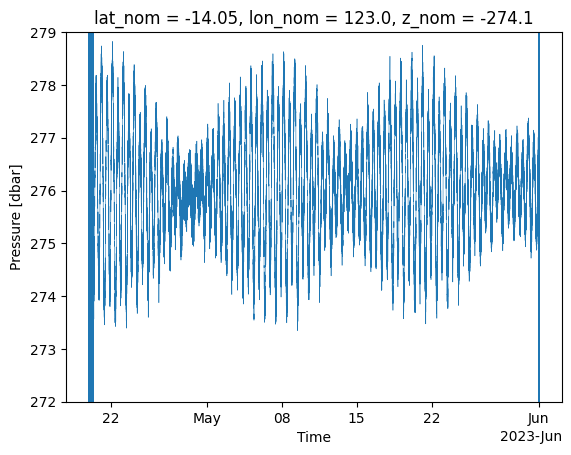

In [6]:
ds_uv['pressure'].plot(lw=0.4)
plt.gca().set_ylim(272,279)

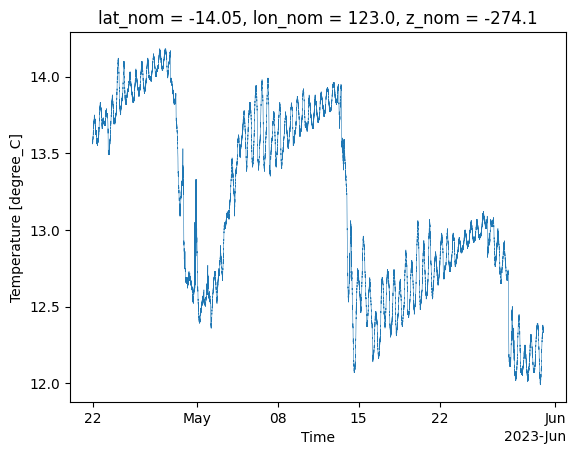

In [7]:
t1 = np.datetime64('2023-04-22 00:00:00')
t2 = np.datetime64('2023-05-31 00:00:00')
series1 = ds_uv['temperature'].sel(time=slice(t1,t2))
series1.plot(lw=0.4)


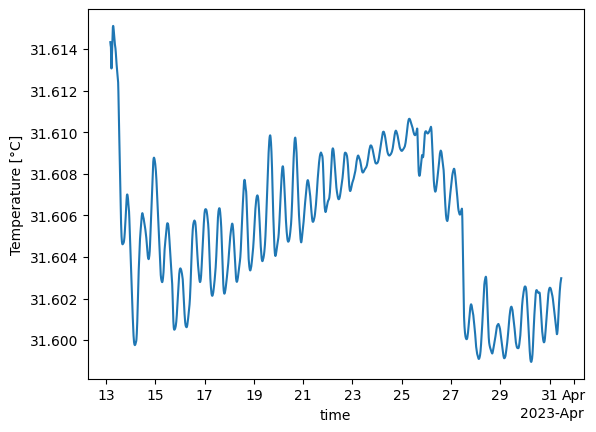

In [8]:
ds_Pcal = ds_P.isel(time=slice(None,None,16*64))

ds_Pcal['Temperature'].plot()

[61.71462655 -0.52904219 91.7724557 ] 0.4113602555100856
[64.80035788 -0.52904219 91.7724557 ] 0.5022222291392135
[61.71462655 -0.5554943  91.7724557 ] 0.41124481975340327
[61.71462655 -0.52904219 96.36107848] 0.4139386235371743
[58.62889522 -0.54667693 94.83153756] 0.5442634827204788
[63.25749221 -0.53345087 92.53722616] 0.4520612264183141
[60.17176089 -0.54226824 94.06676709] 0.4534347972882333
[62.48605938 -0.53565522 92.9196114 ] 0.39804642697835585
[62.2289151  -0.55108561 87.94860338] 0.42263445851867276
[61.84319869 -0.53455305 94.25795971] 0.3988904036990936
[62.31462986 -0.55475952 94.19422884] 0.4231784190057124
[61.86462738 -0.53547152 92.37789898] 0.3931230537613418
[62.41463042 -0.51495889 94.59785769] 0.4058609435430663
[62.23962945 -0.52509274 93.89150719] 0.4269548657547676
[62.17534338 -0.53556337 92.64875519] 0.4185652725190661
[61.85391303 -0.53501228 93.31792935] 0.3960015896115311
[61.78962696 -0.54548291 92.07517734] 0.4079074657142957
[61.4967682  -0.54174778 92.

<xarray.DataArray 'time' ()> Size: 8B
array('2023-05-13T15:24:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2023-03-13T04:12:56

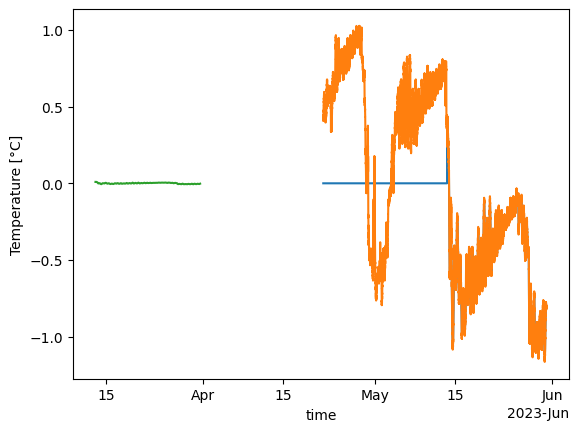

In [9]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.interpolate import interp1d
###
# Inputs
series1 = ds_uv['temperature'].sel(time=slice(t1,t2)) # Calibration/baseline data
series2 = ds_Pcal['Temperature'] # Data to calibrate

# Remove the mean from both
T_mu = series1.mean()
series1 -= T_mu
series2 -= series2.mean()

####

# Define cost function to minimize
def cost(params):
    
    #lag_days, scale, offset = params
    lag_days, p0, p1 = params
    lag = int(round(lag_days*86400.))

    # Shift time2 by lag days
    shifted_time2 = series2.time + pd.Timedelta(seconds=lag)

    # Transformed y data
    y = 1*series2.values 
    #yval = y * scale + offset
    yval = p0 + p1 * y #+ p2 * y**2.
    
    # Interpolate series2 to match time1
    fill_value = 999
    interp_func = interp1d(
        x=shifted_time2.astype(np.int64),
        y=yval,
        bounds_error=False,
        fill_value=fill_value,
    )

    # Convert time1 to int64 for interpolation
    time1_int = series1.time.astype(np.int64)
    series2_interp = interp_func(time1_int)

    idx = series2_interp == fill_value
    series2_interp[idx] = 0.

    y2 = series1.values*1
    y2[idx] = 0.
    

    # Compute mean squared error
    # cost = np.mean((series1.values - series2_interp)**2)
    cost = np.mean(np.abs(series1.values - series2_interp))

    print(params, cost)
    return cost

# Initial guess for lag, scale, offset
# initial_guess = [55.,-20, 100, 0]
# bounds = ([0, 80],[-30,30], [-1e3,1e3], [-1, 1])
# initial_guess = [55.,0, 100, ]
initial_guess = [61.46462655+0.25, -0.52904219, 91.7724557]
# bounds = ([0, 80],[-30,30], [-1e3,1e3], )
bounds = None
# Run optimization
result = minimize(cost, initial_guess, 
                  bounds=bounds,
                  method='nelder-mead')

# # Extract optimal parameters
print(result.x)


# optimal_lag = 60.
# # optimal_scale = 1.
# # optimal_offset = 0.
# p0, p1, p2 = 0, 100, 0
# optimal_lag, p0, p1 = [61.46462655, -0.52904219, 91.7724557]
# optimal_lag, p0, p1 = [61.46462655, -0.25, 91.7724557]
# optimal_lag, p0, p1 = [61.46602033, -0.26330282, 91.56441749]
optimal_lag, p0, p1 = result.x

# Apply lag to time2

lag = int(round(optimal_lag*86400.))
shifted_time2 = series2.time + pd.Timedelta(seconds=lag)

y = 1*series2.values
#yval = y * scale + offset
yval = p0 + p1 * y #+ p2 * y**2.

# Interpolate series2 to match time1
interp_func = interp1d(
    x=shifted_time2.astype(float),
    y=yval,
    bounds_error=False,
    fill_value=0.
)

# Convert time1 to int64 for interpolation
time1 = series1.time
time1_float = time1.astype(float)
# new_series = pd.Series(interp_func(time1_int), index=time1)
new_series = xr.DataArray(interp_func(time1_float), coords={'time':time1})

# This is the data to save
scaled_series = xr.DataArray(yval, coords={'time':shifted_time2 })

# new_series 
new_series.plot()
series1.plot() 
series2.plot()

#test_series.time[0].values,series1.time[0].values
shifted_time2[0]

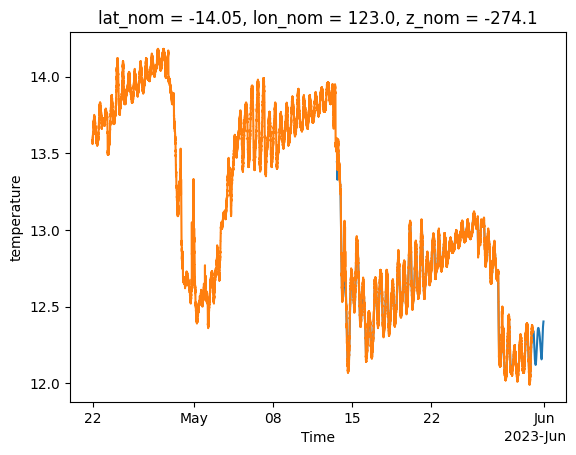

In [10]:
t1 = np.datetime64('2023-05-09 00:00:00')
t2 = np.datetime64('2023-05-31 12:00:00')
# new_series.plot()
(scaled_series + T_mu).plot()

(series1 + T_mu).plot()
# series2.plot()
# plt.xlim(t1,t2)

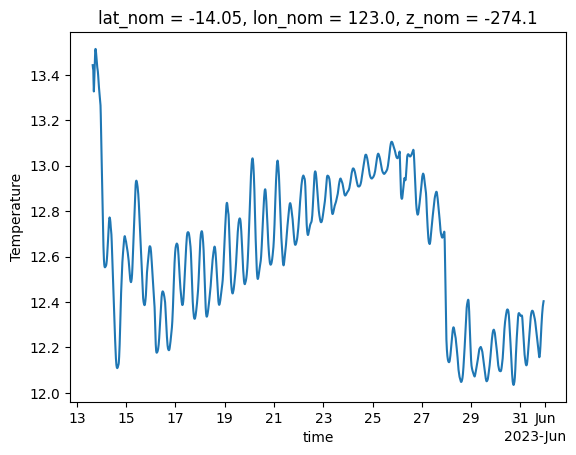

In [11]:
ds_Pcal = ds_P.isel(time=slice(None,None,16*64))

ds_Pcal_shift = ds_Pcal.copy()

# Shift the time
new_time = ds_Pcal.time + pd.Timedelta(seconds=lag)
ds_Pcal_shift = ds_Pcal_shift.assign_coords(time = new_time)

# scale the temperature
Traw = ds_Pcal_shift['Temperature']
ds_Pcal_shift['Temperature'] = (Traw-Traw.mean()) * p1+ p0+T_mu

ds_Pcal_shift['Temperature'].plot()

# Calibrate the pressure

In [12]:
#!pip install pytmd --upgrade

In [13]:
## Option 3: use the average pressure from the other two moorings' BPR
etadir = '../DATA/'
ds_bp1 = xr.open_dataset(f'{etadir}/mooring_sealevel_W310_v3.nc')
ds_bp2 = xr.open_dataset(f'{etadir}/mooring_sealevel_S245_v3.nc')

series1 = 0.5*ds_bp1['eta_b'] + 0.5*ds_bp2['eta_b']
P_mu = 276.

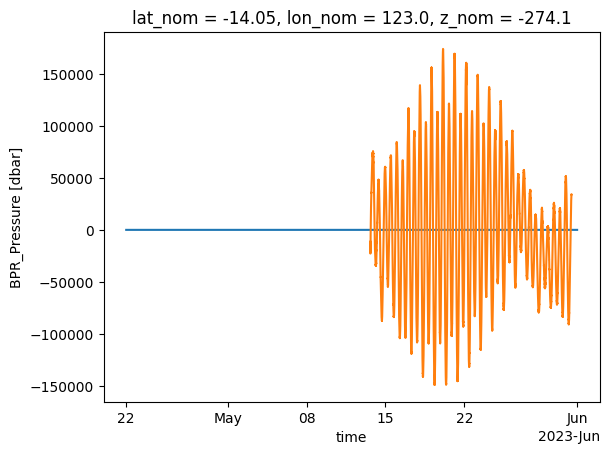

In [20]:
# Inputs
t1 = np.datetime64('2023-05-09 00:00:00')
t2 = np.datetime64('2023-05-31 12:00:00')
# t1 = np.datetime64('2023-05-09 00:00:00')
# t2 = np.datetime64('2023-05-25 12:00:00')
# series1 = ds_uv['pressure'].sel(time=slice(t1,t2)) # Calibration/baseline data
series2 = ds_Pcal_shift['BPR_Pressure'].sel(time=slice(t1,t2)) # Data to calibrate
series2 -= series2.mean()

series1.plot()
series2.plot()

In [21]:

####

# Define cost function to minimize
def cost(params):
    
    #lag_days, scale, offset = params
    p0, p1 = params
    # p0, p1, p2, p3 = params
    
    # Shift time2 by lag days
    shifted_time2 = series2.time #+ pd.Timedelta(seconds=lag)

    # Transformed y data
    y = 1*series2.values 
    yval = p0 + y * p1 
    # yval = p0 + p1 * y + p2 * y**2. + p3 * y**3.
    
    # Interpolate series2 to match time1
    fill_value = 999
    interp_func = interp1d(
        x=shifted_time2.astype(np.int64),
        y=yval,
        bounds_error=False,
        fill_value=fill_value,
    )

    # Convert time1 to int64 for interpolation
    time1_int = series1.time.astype(np.int64)
    series2_interp = interp_func(time1_int)

    idx = series2_interp == fill_value
    series2_interp[idx] = 0.

    y2 = series1.values*1
    y2[idx] = 0.
    

    # Compute mean squared error
    # cost = np.mean((series1.values - series2_interp)**2)
    cost = np.mean(np.abs(series1.values - series2_interp))

    print(params, cost)
    return cost

initial_guess = [ 0, 1e-3]
# initial_guess = [ 0, 1e-3, 1e-10, 1e-10]


bounds = None
# Run optimization
result = minimize(cost, initial_guess, 
                  bounds=bounds,
                  method='nelder-mead')

# # Extract optimal parameters
print(result.x)
# p0_p, p1_p, p2_p, p3_p = result.x
# new_series = p0_p + p1_p * series2 + p2_p * series2**2. + p3_p * series2**3. #+ P_mu

p0_p, p1_p = result.x
Pcal = p0_p + p1_p * series2 


[0.    0.001] 26.07474900884786
[0.00025 0.001  ] 26.074744985340505
[0.      0.00105] 27.37139267312134
[0.00025 0.00095] 24.77810298414277
[0.000375 0.0009  ] 23.48146046340427
[0.000625 0.0009  ] 23.48145643121621
[0.0009375 0.00085  ] 22.184812293019807
[0.0010625 0.00075  ] 19.591537619575902
[0.00146875 0.000625  ] 16.34996054720483
[0.00203125 0.000575  ] 15.053330619726417
[0.00285937 0.0004125 ] 10.839344509235078
[0.00339063 0.0001875 ] 5.004957205738278
[ 0.00461719 -0.00014375] 4.544744008155645
[ 0.00600781 -0.00035625] 10.054928294565917
[ 0.00776563 -0.0009125 ] 24.47987990654964
[4.0859375e-03 8.1250000e-05] 2.251381274170155
[0.00269531 0.00029375] 7.759977066925303
[0.00352344 0.00013125] 3.5467797179664866
[0.00299219 0.00035625] 9.380678713511895
[ 4.2109375e-03 -1.8750000e-05] 1.3071136123691198
[ 4.7734375e-03 -6.8750000e-05] 2.600739900867217
[ 4.4609375e-03 -1.8750000e-05] 1.3071156393140329
[ 0.00458594 -0.00011875] 3.896618246167533
[4.2109375e-03 3.1250000e-0

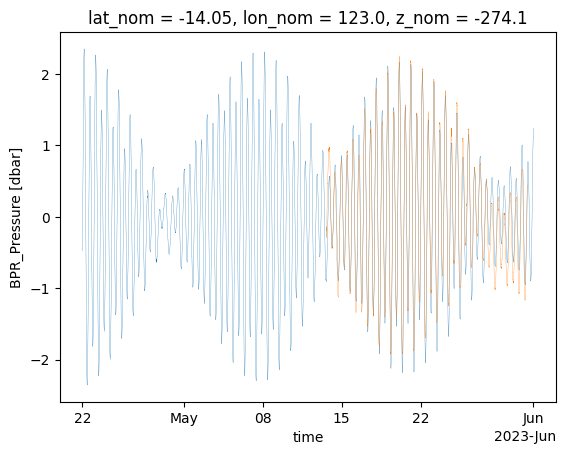

In [22]:
(series1).plot(lw=0.2)

Pcal.plot(lw=0.2)

# plt.ylim(-3,3)

In [23]:
Tcalstr = f'Temperature calibrations: lag {lag}, p0 {p0}, p1 {p1}, mean {T_mu.values}'
print(Tcalstr)

# Pcalstr = f'Pressure calibrations:  p0 {p0_p}, p1 {p1_p},  p2 {p2_p},  p3 {p3_p}, mean {P_mu.values}'
Pcalstr = f'Pressure calibrations:  p0 {p0_p}, p1 {p1_p}, mean {P_mu}'

print(Pcalstr)

Temperature calibrations: lag 5310664, p0 -0.5341642229882914, p1 91.56453811696574, mean 13.154180526733398
Pressure calibrations:  p0 0.003463845729827875, p1 1.289920806884422e-05, mean 276.0


# Do a temperature dependent pressure scaling re: RBR manual



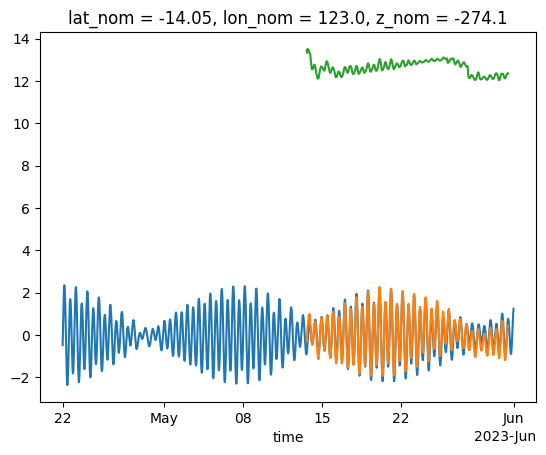

In [26]:
Tcal = (Traw-Traw.mean()) * p1+ p0+T_mu

series2 = Pcal 

series1.plot()
series2.plot()

Tseries2 = Tcal.sel(time=slice(t1,t2)) 
Tseries2.plot()

[1.2e+01 0.0e+00 1.0e-03 1.0e-10 1.0e-10] 0.5677633422812236
[1.26e+01 0.00e+00 1.00e-03 1.00e-10 1.00e-10] 0.5678753511025508
[1.2e+01 2.5e-04 1.0e-03 1.0e-10 1.0e-10] 0.5677401494045848
[1.20e+01 0.00e+00 1.05e-03 1.00e-10 1.00e-10] 0.5677576343963981
[1.20e+01 0.00e+00 1.00e-03 1.05e-10 1.00e-10] 0.5677633422806063
[1.20e+01 0.00e+00 1.00e-03 1.00e-10 1.05e-10] 0.5677633422812473
[1.14e+01 1.00e-04 1.02e-03 1.02e-10 1.02e-10] 0.5676397527491145
[1.08e+01 1.50e-04 1.03e-03 1.03e-10 1.03e-10] 0.5675268244237316
[1.152e+01 1.600e-04 1.032e-03 1.032e-10 9.620e-11] 0.5676540187372436
[1.1328e+01 2.2400e-04 1.0448e-03 1.0448e-10 9.9680e-11] 0.5676097189293875
[1.10592e+01 3.13600e-04 1.06272e-03 9.92720e-11 9.95520e-11] 0.5675483281311436
[1.068288e+01 4.390400e-04 1.017808e-03 1.039808e-10 9.937280e-11] 0.5674886883974863
[1.002432e+01 6.585600e-04 1.001712e-03 1.059712e-10 9.905920e-11] 0.5673927818862017
[9.8926080e+00 3.5246400e-04 1.0684928e-03 1.0636928e-10 9.8996480e-11] 0.56736950

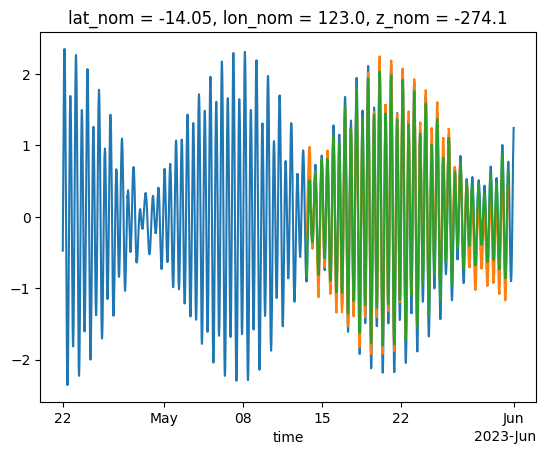

In [32]:

####

# Define cost function to minimize
def cost(params):

    Pcal = 0
    #Tcal = 12
    Tcal, p1, p2, p3, p4 = params
    
    # Shift time2 by lag days
    shifted_time2 = series2.time #+ pd.Timedelta(seconds=lag)

    # Transformed y data
    P = 1*series2.values 
    T = 1*Tseries2.values
    Pcorr = Pcal + ( (P-Pcal) - p1 * (T-Tcal) - p2 * (T-Tcal)**2 - p3*(T-Tcal)**3 ) / (1+p4*(T-Tcal))
    
    # Interpolate series2 to match time1
    fill_value = 999
    interp_func = interp1d(
        x=shifted_time2.astype(np.int64),
        y=Pcorr,
        bounds_error=False,
        fill_value=fill_value,
    )

    # Convert time1 to int64 for interpolation
    time1_int = series1.time.astype(np.int64)
    series2_interp = interp_func(time1_int)

    idx = series2_interp == fill_value
    series2_interp[idx] = 0.

    y2 = series1.values*1
    y2[idx] = 0.
    

    # Compute mean squared error
    # cost = np.mean((series1.values - series2_interp)**2)
    cost = np.mean(np.abs(series1.values - series2_interp))

    print(params, cost)
    return cost

initial_guess = [12, 0, 1e-3, 1e-10, 1e-10]
# initial_guess = [0, 1e-3, 1e-10, 1e-10]


bounds = None
# Run optimization
result = minimize(cost, initial_guess, 
                  bounds=bounds,
                  method='nelder-mead')

# # Extract optimal parameters
print(result.x)

Tcal, b1, b2, b3, b4 = result.x

# Tcal = 10
Pcal = 0
P = series2 
T = Tseries2
Pcorr = Pcal + ( (P-Pcal) - b1 * (T-Tcal) - b2 * (T-Tcal)**2 - b3*(T-Tcal)**3 ) / (1+b4*(T-Tcal))

series1.plot()
series2.plot()
Pcorr.plot()

In [33]:
Pcalstr2 = f'Pressure (temperature) calibrations:  Kp1 {b1}, Kp2 {b2}, Kp3 {b3}, Kp4 {b4}, mean {P_mu}'


In [34]:
# Go back and apply the calibration to the original data
ds_P = xr.open_dataset(rbrfilename)

In [43]:
ds_P_shift = ds_P.copy()

# Shift the time
new_time = ds_P_shift.time + pd.Timedelta(seconds=lag)
ds_P_shift = ds_P_shift.assign_coords(time = new_time)

# scale the temperature
Traw = ds_P_shift['Temperature']
ds_P_shift['Temperature'] = (Traw-Traw.mean()) * p1+ p0+T_mu

# scale the pressure
Praw = ds_P_shift['BPR_Pressure']
P = (Praw-Praw.mean()) * p1_p+ p0_p # + P_mu

# Scale the pressure based on termpature
Pcal = 0
T = ds_P_shift['Temperature']
Pcorr = Pcal + ( (P-Pcal) - b1 * (T-Tcal) - b2 * (T-Tcal)**2 - b3*(T-Tcal)**3 ) / (1+b4*(T-Tcal))
ds_P_shift['BPR_Pressure'] = Pcorr + P_mu

In [44]:
P.mean(), Pcorr.mean()

(<xarray.DataArray 'BPR_Pressure' ()> Size: 8B
 array(0.00346385)
 Coordinates:
     lat_nom  float64 8B -14.05
     lon_nom  float64 8B 123.0
     z_nom    float64 8B -274.1,
 <xarray.DataArray ()> Size: 8B
 array(0.04109897)
 Coordinates:
     lat_nom  float64 8B -14.05
     lon_nom  float64 8B 123.0
     z_nom    float64 8B -274.1)

In [45]:

#output
ds_P_shift.attrs.update({'rawfile' : rbrfilename})
ds_P_shift.attrs.update({'Temperature info':  Tcalstr})
ds_P_shift.attrs.update({'Pressure info (1)':  Pcalstr})
ds_P_shift.attrs.update({'Pressure info (2)':  Pcalstr2})

ds_P_shift.attrs

                        
                    

{'title': 'Measured data from an RBR Data Logger',
 'institution': 'The University of Western Australia',
 'institution_division': 'Ocean Dynamics',
 'source': '',
 'project': '',
 'history': '',
 'references': '',
 'comment': '',
 'Conventions': 'CF-1.7',
 'trip': '',
 'trip_deployed': '',
 'site': '',
 'site_station': '',
 'instrument_make': '',
 'instrument_model': '',
 'instrument_serial_number': '',
 'raw_file_name': '',
 'raw_file_directory': '',
 'raw_file_attributes': '',
 'last_export_file_name': '',
 'last_export_directory': '',
 'last_load_file_name': '',
 'last_load_directory': '',
 'outfile_append': '',
 'disclaimer': '',
 'nominal_latitude': '',
 'nominal_longitude': '',
 'nominal_site_depth': '',
 'pressure_sensor_height_asb': '',
 'nominal_instrument_height_asb': '',
 'nominal_instrument_orientation': '',
 'timezone': '',
 'process_level': 'Process Level 0',
 'is_profile_data': 0,
 'rawfile': '../../../SWOT_Cruise/RBRqu/N280_RBRQu_213896_20230818_1714_rebuilt.nc',
 'Tem

In [46]:
%%time
ds_P_shift.to_netcdf(outfilename)
print('Done. ', outfilename)

Done.  ../../../SWOT_Cruise/RBRqu/N280_RBRQu_213896_20230818_1714_W310S245_Tcalibration.nc
CPU times: user 786 ms, sys: 1.84 s, total: 2.62 s
Wall time: 2.98 s


In [61]:
ds_P

<xarray.Dataset> Size: 809MB
Dimensions:          (time: 25295878)
Coordinates:
  * time             (time) datetime64[ns] 202MB 2023-03-13T04:12:56 ... 2023...
Data variables:
    BPR_Pressure     (time) float64 202MB ...
    Temperature      (time) float64 202MB ...
    BPR_Temperature  (time) float64 202MB ...
Attributes: (12/34)
    title:                           Measured data from an RBR Data Logger
    institution:                     The University of Western Australia
    institution_division:            Ocean Dynamics
    source:                          
    project:                         
    history:                         
    ...                              ...
    pressure_sensor_height_asb:      
    nominal_instrument_height_asb:   
    nominal_instrument_orientation:  
    timezone:                        
    process_level:                   Process Level 0
    is_profile_data:                 0